In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import ndiffs, nsdiffs
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as scs
from stationarityTestUtils import test_autocorrelation

In [32]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [33]:
def arima_diagnostics(resids, n_lags=40):
    
    #도식화(2x2)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

    r = resids
    
    resids = (r - np.nanmean(r)) / np.nanstd(r)      #잔차표준화
    resids_nonmissing = resids[~(np.isnan(resids))]  
    
    #1번 도식화(잔차 시계열성)
    sns.lineplot(x=np.arange(len(resids)), y=resids, ax=ax1)
    ax1.set_title('잔차 시계열성')

    #2번 도식화(잔차 분포)
    x_lim = (-1.96 * 2, 1.96 * 2)
    r_range = np.linspace(x_lim[0], x_lim[1])
    norm_pdf = scs.norm.pdf(r_range)
    
    sns.histplot(resids_nonmissing, stat='density', kde=True, ax=ax2)

    ax2.plot(r_range, norm_pdf, 'g', lw=2, label='N(0,1)')
    ax2.set_title('잔차 분포')
    ax2.set_xlim(x_lim)
    ax2.legend()
        
    # Q-Q plot
    qq = sm.qqplot(resids_nonmissing, line='s', ax=ax3)
    ax3.set_title('Q-Q plot(정규성 확인)')

    # ACF plot
    plot_acf(resids, ax=ax4, lags=n_lags, alpha=0.05)
    ax4.set_title('ACF plot(자기상관 확인)')

    fig.set_size_inches(16, 10)
    
    return fig

### 데이터 불러오기(구글 2015~2018년도)

In [34]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GOOG"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")

df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               # Date를 인덱스로 설정
df = df.loc['2015-01-01':'2018-12-31']  # 분석 기간

goog = df.resample('W').last().adj_close

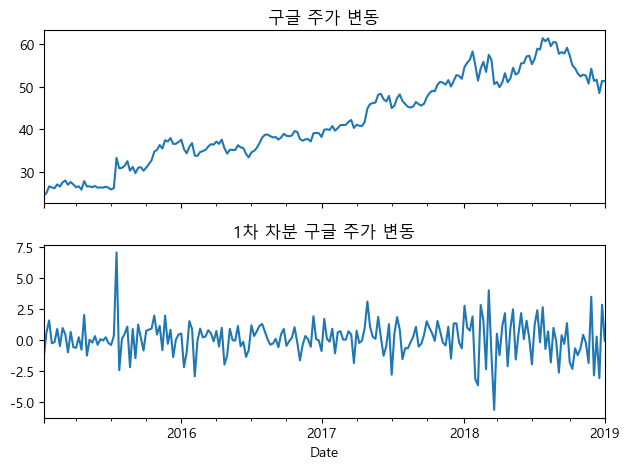

In [35]:
goog_diff = goog.diff().dropna()

fig, ax = plt.subplots(2, sharex=True)
goog.plot(title = "구글 주가 변동", ax=ax[0])
goog_diff.plot(title='1차 차분 구글 주가 변동', ax=ax[1])

plt.tight_layout()
plt.show()

### 차분 데이터 정상성 검정

In [36]:
print(f"차분횟수추정 (ADF): {ndiffs(df.adj_close, test='adf')}")
print(f"차분횟수추정 (KPSS): {ndiffs(df.adj_close, test='kpss')}")
print(f"차분횟수추정 (PP): {ndiffs(df.adj_close, test='pp')}")
print(f"계절성차분횟수추정 (OSCB): {nsdiffs(df.adj_close, m=12, test='ocsb')}")
print(f"계절성차분횟수추정 (CH): {nsdiffs(df.adj_close, m=12, test='ch')}")

차분횟수추정 (ADF): 1
차분횟수추정 (KPSS): 1
차분횟수추정 (PP): 0
계절성차분횟수추정 (OSCB): 0
계절성차분횟수추정 (CH): 0


ADF 검정통계량: -12.82 (p-value: 0.00) -> 검정결과:정상성 데이터
KPSS 검정통계량: 0.09 (p-value: 0.10) -> 검정결과:정상성 데이터


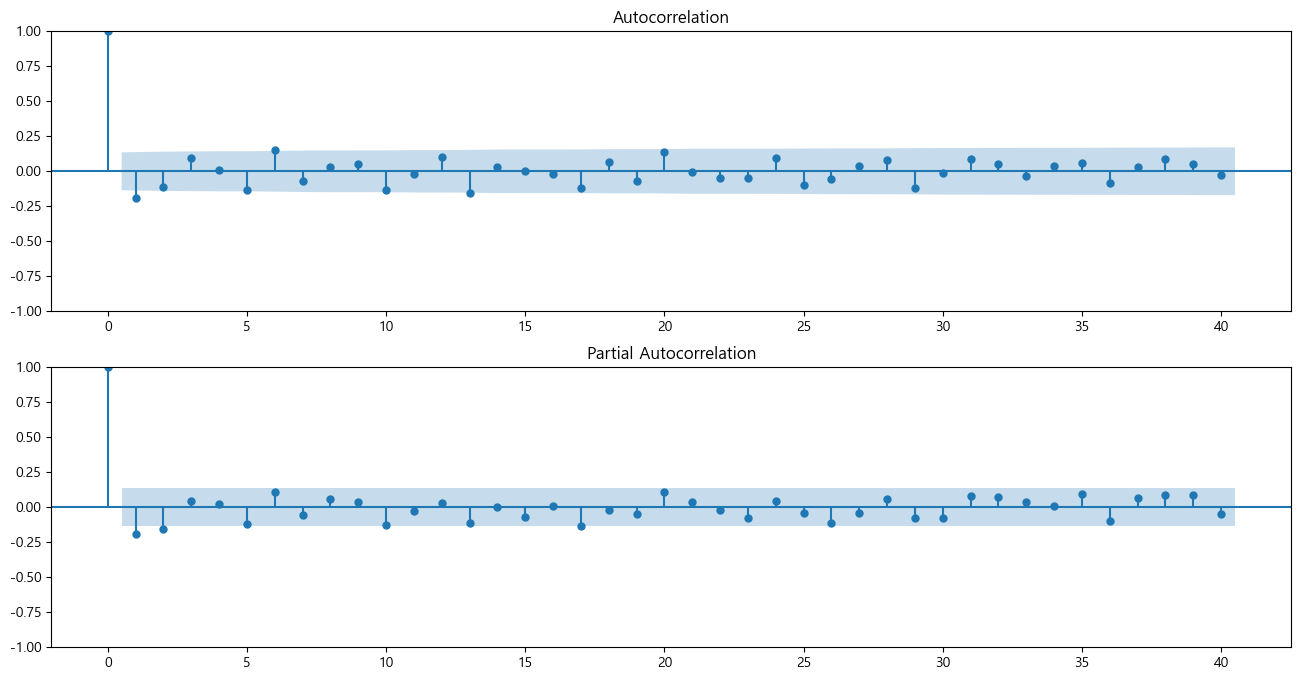

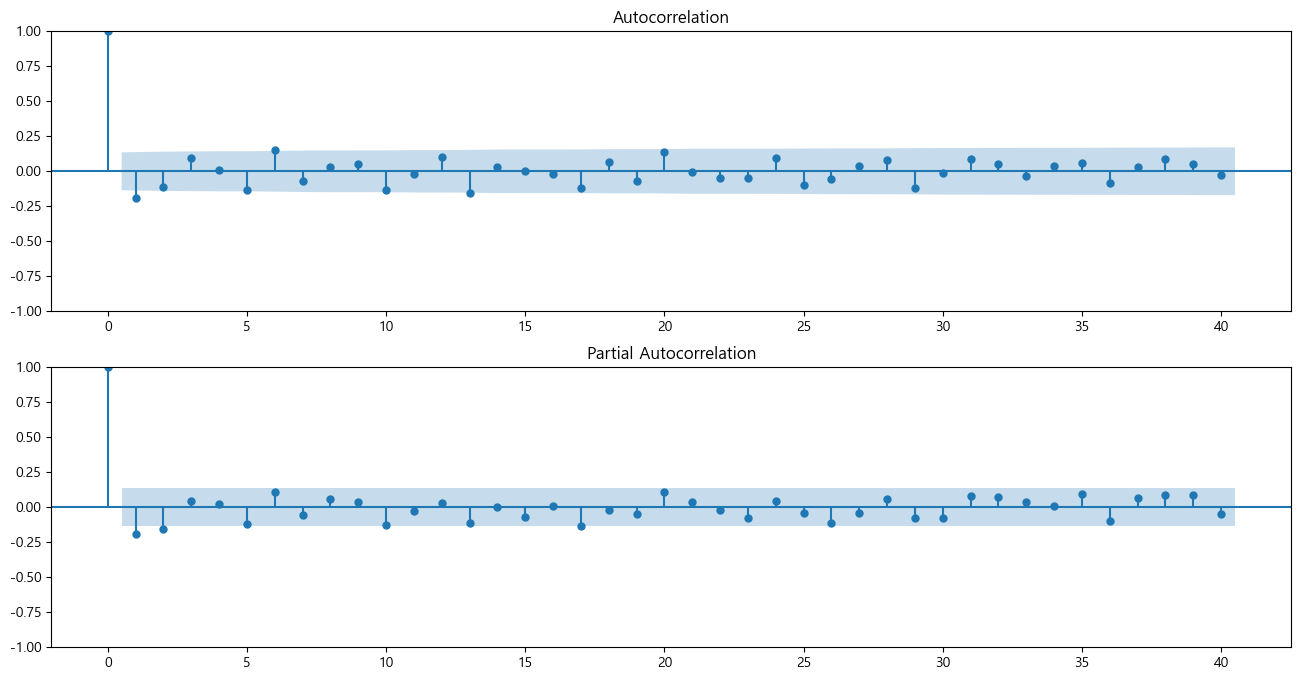

In [37]:
test_autocorrelation(goog_diff)

In [38]:
arima = ARIMA(goog, order=(2, 1, 1)).fit()
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              adj_close   No. Observations:                  210
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -364.840
Date:                Wed, 16 Sep 2026   AIC                            737.680
Time:                        23:16:15   BIC                            751.050
Sample:                    01-04-2015   HQIC                           743.086
                         - 01-06-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4063      0.394     -1.031      0.303      -1.179       0.366
ar.L2         -0.1835      0.081     -2.258      0.024      -0.343      -0.024
ma.L1          0.2053      0.402      0.510      0.610      -0.583       0.994
sigma2         1.9213      0.119     16.194      0.000       1.689       2.154
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               109.58
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.80   Skew:                             0.12
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 잔차 기반 도식화

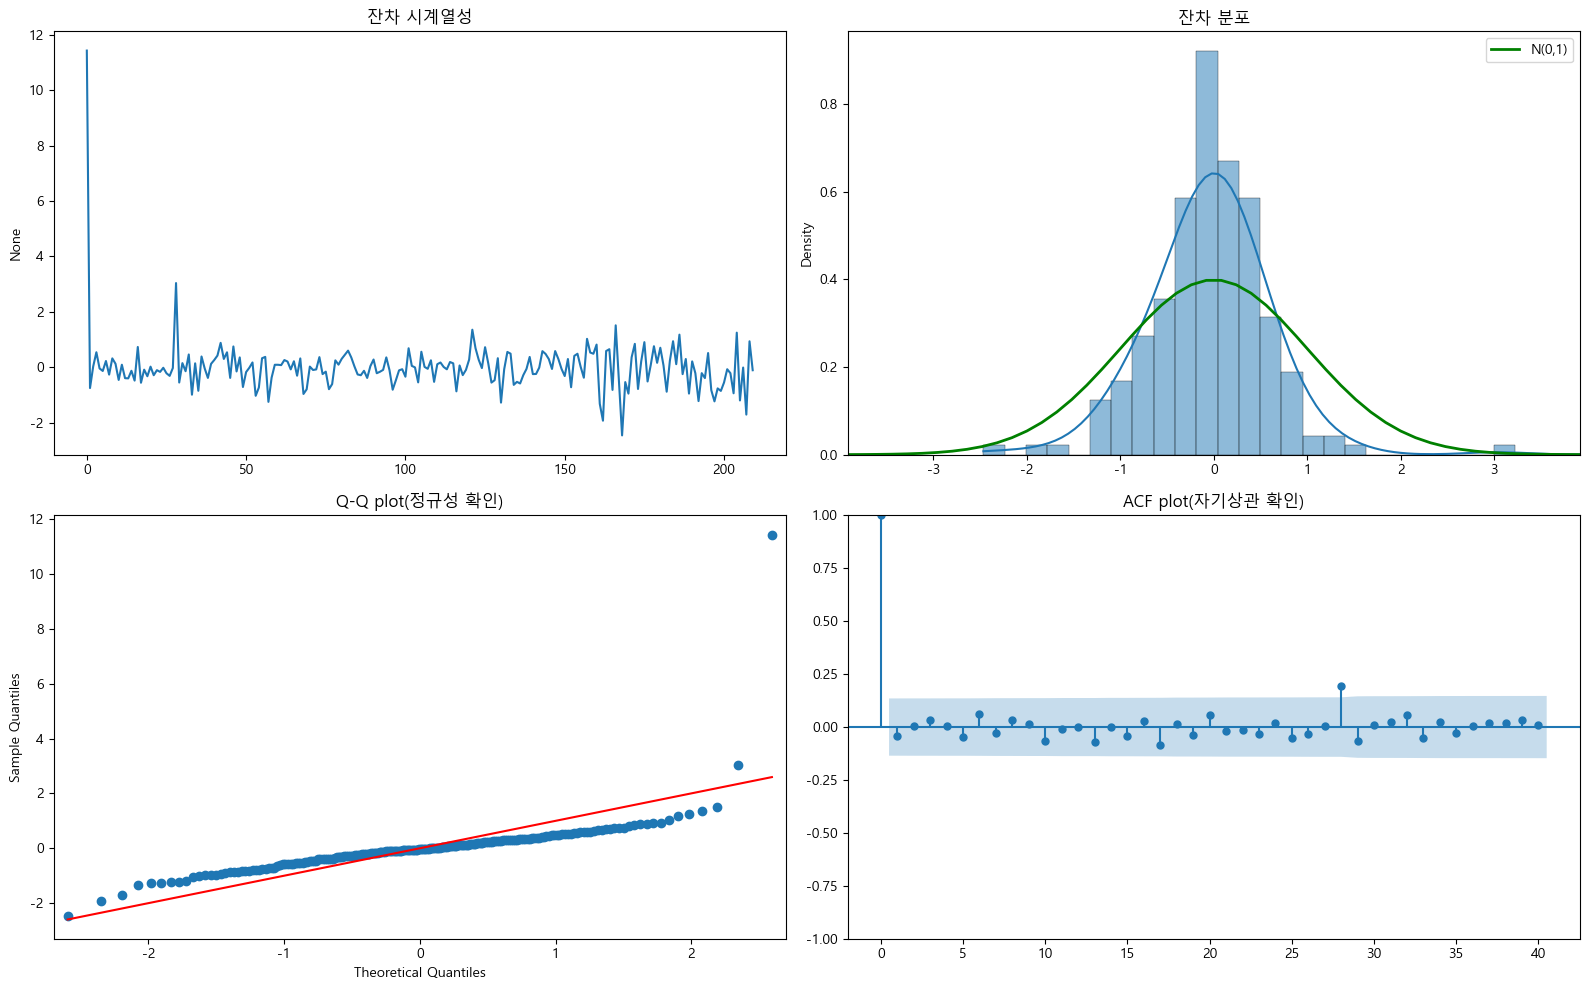

In [39]:
arima_diagnostics(arima.resid)

plt.tight_layout()
plt.show()

### Ljung-Box

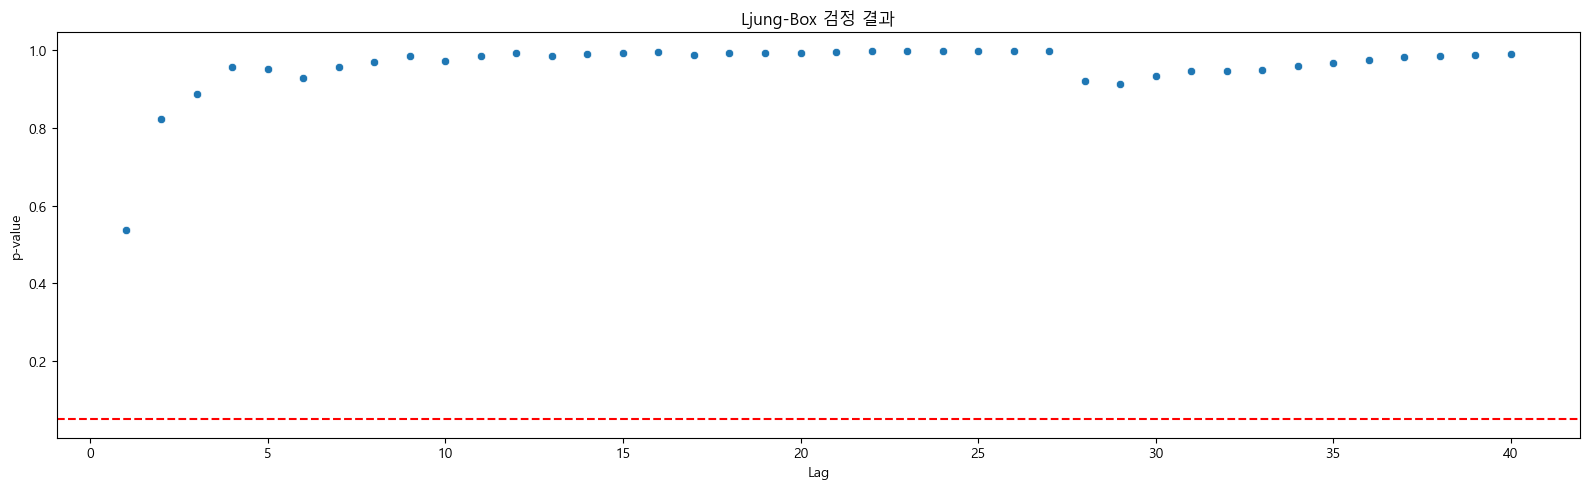

In [42]:
ljung_box_results = acorr_ljungbox(arima.resid, lags=40)

fig, ax = plt.subplots(1, figsize=(16, 5))

sns.scatterplot(
    x=range(1, len(ljung_box_results) + 1),
    y=ljung_box_results['lb_pvalue'],
    ax=ax
)

ax.axhline(0.05, ls='--', c='r')

ax.set(
    title='Ljung-Box 검정 결과',
    xlabel='Lag',
    ylabel='p-value'
)

plt.tight_layout()
plt.show()